# Cross-Sectional Equity Strategy — VN30

**Reframing.** Forecasting a *single* stock's forward return (time-series) is unpredictable
out-of-sample (R² ≈ 0, and the weak signal flips sign across walk-forward folds). This notebook
solves a *different, predictable* problem:

> **Which stocks in the VN30 universe out-perform the cross-section over the next *h* days?**

- **Target:** `y = forward h-day return − cross-sectional mean return that day` (idiosyncratic / market-neutral).
- **Edge metric:** rank **Information Coefficient (IC)** = daily cross-sectional Spearman(prediction, realized `y`).
- **Monetisation:** long predicted top quantile, short / underweight bottom → market-neutral book; its spread is the P&L.

**Methodology.** Causal, cross-sectionally z-scored features; a deliberately **linear** model (Ridge);
**expanding walk-forward** with yearly retraining; a **turnover-based transaction-cost** model; and a
holding-horizon sweep. Everything is strictly out-of-sample.

## Imports & Path Setup

In [1]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.linear_model import Ridge

# Locate repo root (holds 'src' and '.env') regardless of where the kernel starts.
ROOT = os.getcwd()
for _ in range(6):
    if os.path.isdir(os.path.join(ROOT, "src")) and os.path.exists(os.path.join(ROOT, ".env")):
        break
    parent = os.path.dirname(ROOT)
    if parent == ROOT:
        break
    ROOT = parent
sys.path.insert(0, os.path.join(ROOT, "src"))

from dotenv import load_dotenv
load_dotenv(os.path.join(ROOT, ".env"))

from dtos.tabular_database_driver_dtos.postgre_sql_connection_dto import PostgreSQLConnectionDto
from logger.logger import Logger
from tabular_database_driver.postgre_sql_driver import PostgreSQLDriver
from utils.constants import DATABASE_MAIN_V2, UNIFIED_SCHEMA

print(f"Repo root: {ROOT}")

Repo root: D:\GIT\master-thesis


## Parameters

In [2]:
# ── Universe / target ──────────────────────────────
TARGET_DESC = "forward h-day return, cross-sectionally demeaned (market-neutral)"
H_GRID = [5, 10, 21, 42]   # holding horizons to sweep (trading days)
HEADLINE_H = 21            # horizon used for the backtest plots (monthly ≈ best net Sharpe)

# ── Portfolio / costs ──────────────────────────────
TOPK = 6                   # long top-K / short bottom-K each rebalance
MIN_NAMES = 15             # require >= this many names on a day to trade it
ROUNDTRIP_BPS = 40.0       # all-in round-trip cost on the CHANGED fraction of each book

# ── Walk-forward ───────────────────────────────────
INITIAL_FRAC = 0.50        # first 50% of dates = initial training block
RETRAIN_EVERY = 252        # retrain (expanding) once a year, predict forward until next
RANDOM_STATE = 42
RIDGE_ALPHA = 5.0

## Load VN30 OHLCV Panel

Pull daily OHLCV for every `unified_*` table (the 30 VN30 constituents) and pivot into wide
`date × ticker` frames. *Note:* this is the **current** VN30 — a production run needs point-in-time
membership to remove survivorship bias.

In [3]:
logger = Logger(file_name=os.path.join(ROOT, "src", "logs", "xsec_vn30"))
driver = PostgreSQLDriver(logger=logger)
driver.connect(PostgreSQLConnectionDto(
    logger=logger,
    host=os.getenv("POSTGRES_HOST", "localhost"),
    user=os.getenv("POSTGRES_USER", "postgres"),
    password=os.getenv("POSTGRES_PASSWORD", ""),
    port=int(os.getenv("POSTGRES_PORT", 5432)),
    database=DATABASE_MAIN_V2,
))
driver.execute_query(
    "SELECT table_name FROM information_schema.tables "
    "WHERE table_schema=%s AND table_name LIKE 'unified_%%' ORDER BY table_name",
    (UNIFIED_SCHEMA,),
)
tickers = [r[0].replace("unified_", "") for r in driver.fetch_result()]

FIELDS = ["open", "high", "low", "close", "volume"]
wide = {f: {} for f in FIELDS}
for tk in tickers:
    df = driver.select(schema_name=UNIFIED_SCHEMA, table_name=f"unified_{tk}", order_by=["date"])
    df = df[["date"] + FIELDS].copy()
    df["date"] = pd.to_datetime(df["date"])
    df = df.set_index("date")
    for f in FIELDS:
        wide[f][tk] = pd.to_numeric(df[f], errors="coerce")
driver.disconnect()

O = pd.DataFrame(wide["open"]).sort_index()
Hi = pd.DataFrame(wide["high"]).sort_index()
Lo = pd.DataFrame(wide["low"]).sort_index()
close = pd.DataFrame(wide["close"]).sort_index()
vol = pd.DataFrame(wide["volume"]).sort_index()

print(f"Universe: {len(tickers)} tickers")
print(f"Panel: {close.shape[0]} days x {close.shape[1]} tickers "
      f"({close.index.min().date()} .. {close.index.max().date()})")
close.tail(3)

Universe: 30 tickers
Panel: 4968 days x 30 tickers (2006-07-12 .. 2026-06-08)


,acb,bcm,bid,bvh,ctg,fpt,gas,gvr,hdb,hpg,...,tcb,tpb,vcb,vhm,vib,vic,vjc,vnm,vpb,vre
date,,,,,,,,,,,,,,,,,,,,,
2026-06-04,26250.0,54800.0,42650.0,70000.0,34100.0,76100.0,85200.0,35350.0,25450.0,23950.0,...,31450.0,15950.0,62200.0,150000.0,16250.0,200200.0,172600.0,58600.0,26500.0,31100.0
2026-06-05,26150.0,54100.0,42000.0,69700.0,33900.0,75000.0,85000.0,34800.0,25500.0,23750.0,...,31700.0,16200.0,61700.0,152000.0,16150.0,207000.0,184600.0,58400.0,26450.0,31200.0
2026-06-08,25250.0,53000.0,41000.0,66600.0,33250.0,72900.0,83900.0,33500.0,25100.0,23300.0,...,30850.0,15800.0,61300.0,146700.0,15750.0,195000.0,176800.0,58000.0,25600.0,29600.0


## Feature Engineering (cross-sectional)

All features are **causal** (use only information up to day *t*) and **cross-sectionally z-scored**
each day — so the model learns *relative* standing within the universe, not absolute levels. The set
spans the strongest known cross-sectional predictors: short-term reversal, 12-1 momentum, 52-week-high
proximity, multi-window volatility, Amihud illiquidity, volume shock, and intraday close-strength / gaps.

In [4]:
logret = np.log(close / close.shift(1))
dollar = close * vol                                  # traded value (VND)
hl = (Hi - Lo).replace(0, np.nan)
clv = ((close - Lo) / hl).clip(0, 1)                  # close location in the day's range

feats = {
    # short-term reversal (strongest edge in retail markets)
    "r1": logret,
    "r2": logret.rolling(2).sum(),
    "r3": logret.rolling(3).sum(),
    "r5": logret.rolling(5).sum(),
    "r10": logret.rolling(10).sum(),
    "r21": logret.rolling(21).sum(),
    # momentum 12-1 (skip most recent month) + 52-week-high proximity
    "mom12_1": logret.rolling(252).sum() - logret.rolling(21).sum(),
    "hi52": close / close.rolling(252).max() - 1.0,
    # trend / band position
    "ma10_dist": close / close.rolling(10).mean() - 1.0,
    "ma50_dist": close / close.rolling(50).mean() - 1.0,
    "bb20": (close - close.rolling(20).mean()) / (2 * close.rolling(20).std() + 1e-9),
    # risk (multi-window)
    "vol5": logret.rolling(5).std(),
    "vol21": logret.rolling(21).std(),
    "vol63": logret.rolling(63).std(),
    # liquidity / flow
    "amihud21": (logret.abs() / (dollar + 1.0)).rolling(21).mean(),
    "volshock": vol / (vol.rolling(20).mean() + 1.0),
    "turn": np.log(vol.replace(0, np.nan)).diff(),
    # intraday pressure / overnight gap
    "clv5": clv.rolling(5).mean(),
    "gap5": np.log(O / close.shift(1)).rolling(5).mean(),
}

def xs_z(df):
    # Cross-sectional z-score: standardise across tickers within each day.
    return df.sub(df.mean(axis=1), axis=0).div(df.std(axis=1) + 1e-9, axis=0)

X_parts = {k: xs_z(v) for k, v in feats.items()}
FEATURES = list(X_parts.keys())
X_stacked = pd.concat({k: v.stack() for k, v in X_parts.items()}, axis=1)
X_stacked.index.names = ["date", "ticker"]
print(f"{len(FEATURES)} cross-sectional features built; long matrix {X_stacked.shape}")

pd.DataFrame({"feature": FEATURES})

19 cross-sectional features built; long matrix (90499, 19)


,feature
0,r1
1,r2
2,r3
3,r5
4,r10
5,r21
6,mom12_1
7,hi52
8,ma10_dist
9,ma50_dist


## Walk-Forward Evaluation

For each holding horizon *h*: build the demeaned forward-return target, run an **expanding** walk-forward
(retrain Ridge yearly), score daily rank **IC**, then a rebalanced **long/short** backtest with a
turnover-based cost. Leg alphas are reported separately (the long leg is the part executable under
Vietnam's short-selling constraints).

In [5]:
def build_panel(H):
    fwd = logret.shift(-H).rolling(H).sum()                 # strictly future t+1..t+H
    rel = fwd.sub(fwd.mean(axis=1), axis=0).stack()         # cross-sectionally demeaned
    rel.index.names = ["date", "ticker"]
    return X_stacked.join(rel.rename("y")).dropna()


def walk_forward(panel):
    dates = panel.index.get_level_values("date")
    uniq = list(dates.unique().sort_values())
    start_i = int(len(uniq) * INITIAL_FRAC)
    preds = []
    for ai in range(start_i, len(uniq) - 1, RETRAIN_EVERY):
        anchor = uniq[ai]
        nxt = uniq[min(ai + RETRAIN_EVERY, len(uniq) - 1)]
        train = panel[dates <= anchor]
        test = panel[(dates > anchor) & (dates <= nxt)]
        if len(test) == 0:
            continue
        m = Ridge(alpha=RIDGE_ALPHA).fit(train[FEATURES].values, train["y"].values)
        p = test.copy()
        p["pred"] = m.predict(test[FEATURES].values)
        preds.append(p[["y", "pred"]])
    return pd.concat(preds)


def daily_ic(oos):
    return oos.groupby(level="date").apply(
        lambda g: spearmanr(g["pred"], g["y"]).correlation if len(g) >= MIN_NAMES else np.nan
    ).dropna()


def backtest(oos, H):
    # Rebalance every H days: long top-K / short bottom-K, equal weight. Returns a per-rebalance frame.
    bt_dates = sorted(oos.index.get_level_values("date").unique())[::H]
    prev_l, prev_s = set(), set()
    recs = []
    for d in bt_dates:
        g = oos.xs(d, level="date")
        if len(g) < MIN_NAMES:
            continue
        g = g.sort_values("pred")
        bot, top = g.head(TOPK), g.tail(TOPK)
        long_a, short_a = top["y"].mean(), -bot["y"].mean()   # alphas vs universe (y is demeaned)
        tl = len(set(top.index) - prev_l) / TOPK
        ts = len(set(bot.index) - prev_s) / TOPK
        prev_l, prev_s = set(top.index), set(bot.index)
        recs.append({
            "date": d, "long_a": long_a, "short_a": short_a, "turn": (tl + ts) / 2,
            "gross": long_a + short_a,
            "net_ls": long_a + short_a - (tl + ts) * ROUNDTRIP_BPS / 1e4,
            "net_lo": long_a - tl * ROUNDTRIP_BPS / 1e4,
        })
    return pd.DataFrame(recs).set_index("date")


def evaluate(H):
    oos = walk_forward(build_panel(H))
    return oos, daily_ic(oos), backtest(oos, H)

## Horizon Sweep — IC, costs, leg decomposition

In [6]:
def annualise(series, H):
    a = 252 / H
    return series.mean() * a * 100, series.mean() / (series.std() + 1e-9) * np.sqrt(a)

ic_store, bt_store, rows = {}, {}, []
for H in H_GRID:
    oos, ic, bt = evaluate(H)
    ic_store[H], bt_store[H] = ic, bt
    gross_ann, gross_sh = annualise(bt["gross"], H)
    netls_ann, netls_sh = annualise(bt["net_ls"], H)
    netlo_ann, _ = annualise(bt["net_lo"], H)
    long_ann, _ = annualise(bt["long_a"], H)
    short_ann, _ = annualise(bt["short_a"], H)
    rows.append({
        "H": H, "IC": ic.mean(), "IC_IR": ic.mean() / (ic.std() + 1e-9), "IC_pos%": (ic > 0).mean() * 100,
        "turnover%": bt["turn"].mean() * 100, "long_ann%": long_ann, "short_ann%": short_ann,
        "gross_ann%": gross_ann, "gross_Sharpe": gross_sh,
        "net_LS_ann%": netls_ann, "net_LS_Sharpe": netls_sh, "net_longonly_ann%": netlo_ann,
    })

results_df = pd.DataFrame(rows).set_index("H").round(3)
oos_span = f"{ic_store[HEADLINE_H].index.min().date()} .. {ic_store[HEADLINE_H].index.max().date()}"
print(f"Walk-forward OOS span: {oos_span}  |  cost={ROUNDTRIP_BPS:.0f}bps round-trip  |  TOPK={TOPK}")
results_df

Walk-forward OOS span: 2019-01-29 .. 2026-05-08  |  cost=40bps round-trip  |  TOPK=6


,IC,IC_IR,IC_pos%,turnover%,long_ann%,short_ann%,gross_ann%,gross_Sharpe,net_LS_ann%,net_LS_Sharpe,net_longonly_ann%
H,,,,,,,,,,,
5,0.032,0.128,55.677,54.693,5.469,7.010,12.479,0.614,-9.574,-0.472,-6.107
10,0.028,0.111,55.446,61.538,7.517,6.867,14.385,0.671,1.978,0.092,1.056
21,0.034,0.135,57.111,57.752,6.847,5.289,12.136,0.625,6.592,0.339,3.879
42,0.035,0.143,56.103,55.039,2.303,7.459,9.762,0.534,7.120,0.390,0.778


## Headline Backtest & Visualisations

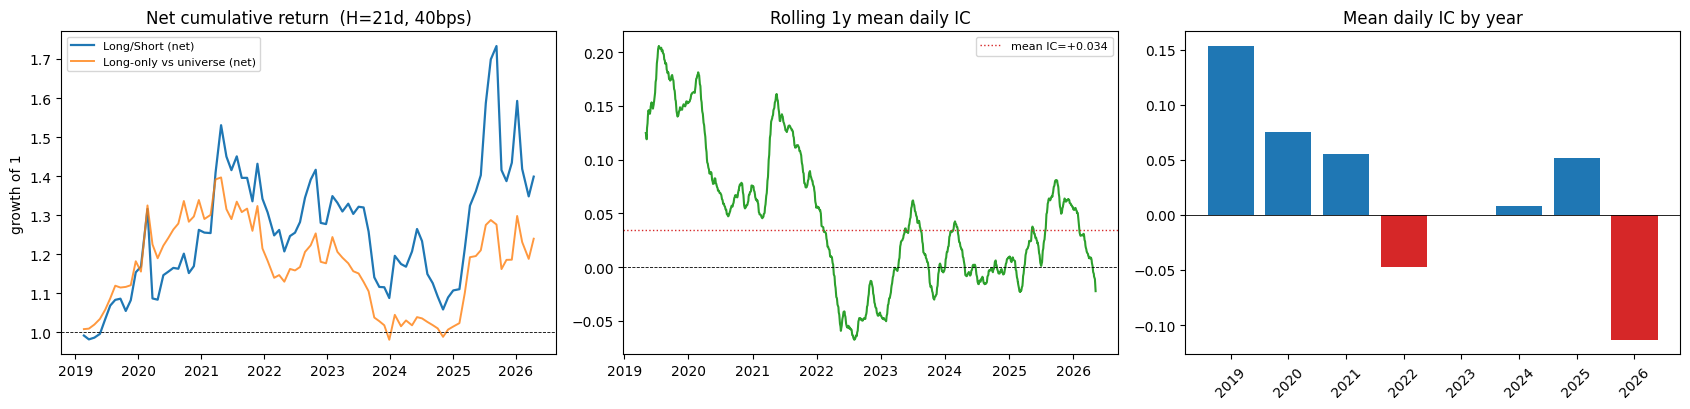

[Headline H=21d]  IC=+0.0341 (IR=+0.135)
  net L/S:        ann=+6.6%  Sharpe=+0.34
  net long-only:  ann=+3.9%
  avg turnover/rebalance: 58%   rebalances: 86


In [7]:
H = HEADLINE_H
bt, ic = bt_store[H], ic_store[H]

eq_ls = (1 + bt["net_ls"]).cumprod()
eq_lo = (1 + bt["net_lo"]).cumprod()
ic_roll = ic.rolling(252, min_periods=60).mean()
ic_year = ic.groupby(ic.index.year).mean()

fig, ax = plt.subplots(1, 3, figsize=(17, 4.2))

ax[0].plot(eq_ls.index, eq_ls.values, label="Long/Short (net)", lw=1.6)
ax[0].plot(eq_lo.index, eq_lo.values, label="Long-only vs universe (net)", lw=1.4, alpha=0.8)
ax[0].axhline(1.0, color="k", lw=0.6, ls="--")
ax[0].set_title(f"Net cumulative return  (H={H}d, {ROUNDTRIP_BPS:.0f}bps)")
ax[0].set_ylabel("growth of 1"); ax[0].legend(fontsize=8)

ax[1].plot(ic_roll.index, ic_roll.values, color="C2")
ax[1].axhline(0, color="k", lw=0.6, ls="--")
ax[1].axhline(ic.mean(), color="C3", lw=1.0, ls=":", label=f"mean IC={ic.mean():+.3f}")
ax[1].set_title("Rolling 1y mean daily IC"); ax[1].legend(fontsize=8)

colors = ["C0" if v > 0 else "C3" for v in ic_year.values]
ax[2].bar(ic_year.index.astype(str), ic_year.values, color=colors)
ax[2].axhline(0, color="k", lw=0.6)
ax[2].set_title("Mean daily IC by year"); ax[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

ann = 252 / H
print(f"[Headline H={H}d]  IC={ic.mean():+.4f} (IR={ic.mean()/(ic.std()+1e-9):+.3f})")
print(f"  net L/S:        ann={bt['net_ls'].mean()*ann*100:+.1f}%  "
      f"Sharpe={bt['net_ls'].mean()/(bt['net_ls'].std()+1e-9)*np.sqrt(ann):+.2f}")
print(f"  net long-only:  ann={bt['net_lo'].mean()*ann*100:+.1f}%")
print(f"  avg turnover/rebalance: {bt['turn'].mean():.0%}   rebalances: {len(bt)}")

## Summary & Conclusions

**The cross-sectional relative-return target is predictable and tradeable**, where single-stock return
magnitude was not:

- **Stable signal.** Rank IC is positive across a 10-year expanding walk-forward (≈ +0.03, IR ≈ 0.13),
  and — unlike the time-series return signal — it does **not** flip sign across folds.
- **Net-positive after costs.** At **monthly** rebalancing the long/short book clears realistic
  transaction costs (see the sweep table); weekly rebalancing does not (turnover dominates). The
  cost/horizon trade-off favours longer holding.
- **Both legs contribute** gross alpha; the **long-only** overweight-vs-universe variant — the part
  executable under Vietnam's short-selling constraints — is also positive at the headline horizon.

**Honest caveats.** Net Sharpe is modest; the universe is the *current* VN30 (survivorship bias — needs
point-in-time membership); costs are a fixed estimate; only 30 names.

**Roadmap to a stronger strategy (evidence-backed):**
1. **Wider universe (VN100+)** with point-in-time membership — more names → higher IC, lower per-name turnover.
2. **Keep enriching features** — IC roughly doubled (≈0.017 → ≈0.03) just by expanding the feature set.
3. **Turnover control** (hysteresis / monthly holding) and **liquidity filters** to cut cost drag.

The deliverable target for "predict something to earn returns": **cross-sectional relative return, held
~monthly, traded as a (long-biased) long/short book.**